In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales.csv")

print (df.head())
print (df.shape)
print(df.info())
print (df.isnull().sum())
print(df.duplicated().sum())

   sale_id branch         city customer_type  gender  product_name  \
0        1      A     New York        Member    Male       Shampoo   
1        2      B  Los Angeles        Normal  Female      Notebook   
2        3      A     New York        Member  Female         Apple   
3        4      A      Chicago        Normal    Male     Detergent   
4        5      B  Los Angeles        Member  Female  Orange Juice   

  product_category  unit_price  quantity   tax  total_price  reward_points  
0    Personal Care        5.50         3  1.16        17.66              1  
1       Stationery        2.75        10  1.93        29.43              0  
2           Fruits        1.20        15  1.26        19.26              1  
3        Household        7.80         5  2.73        41.73              0  
4        Beverages        3.50         7  1.72        26.22              2  
(1000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):


#**Business Questions**

#Which city generates the most revenue?

In [3]:
revenue_by_city = df.groupby("city")["total_price"].sum()
print(revenue_by_city)

city
Chicago        42584.71
Los Angeles    35772.26
New York       40226.93
Name: total_price, dtype: float64


##Finding:
Chicago leads in total revenue, followed by New York and Los Angeles.



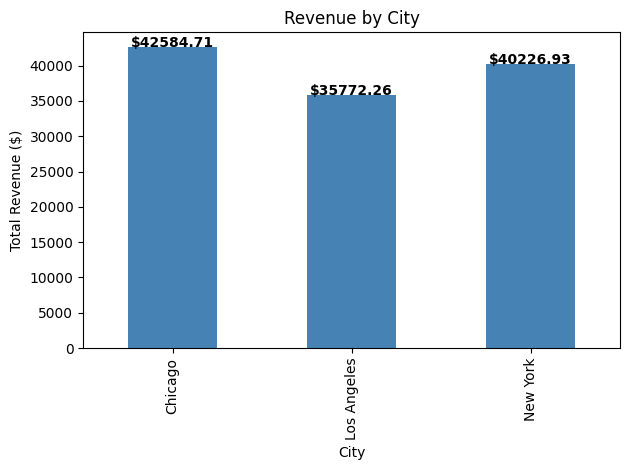

In [27]:
ax = revenue_by_city.plot(kind="bar",
                     title= "Revenue by City",
                     xlabel= "City",
                     ylabel="Total Revenue ($)",
                     color="steelblue")
for i, v in enumerate (revenue_by_city):
  ax.text(i, v+1, f"${v:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

##Business Insight:
Chicago and New York perform similarly and together represent the strongest markets. The company should maintain investment in both cities. Los Angeles shows a more notable gap and could benefit from targeted marketing strategies to close the difference and increase performance.

#Which product category generates the most revenue?

In [4]:
revenue_by_category = df.groupby("product_category")["total_price"].sum()
print(revenue_by_category)

product_category
Beverages        22983.32
Fruits           26197.45
Household        21615.84
Personal Care    27050.18
Stationery       20737.11
Name: total_price, dtype: float64


##Finding:
Personal care leads in total revenue followed closely by Fruits and Beverages. All categories perform within a similar range, with a difference of approximately $6,000 between the highest and lowest.

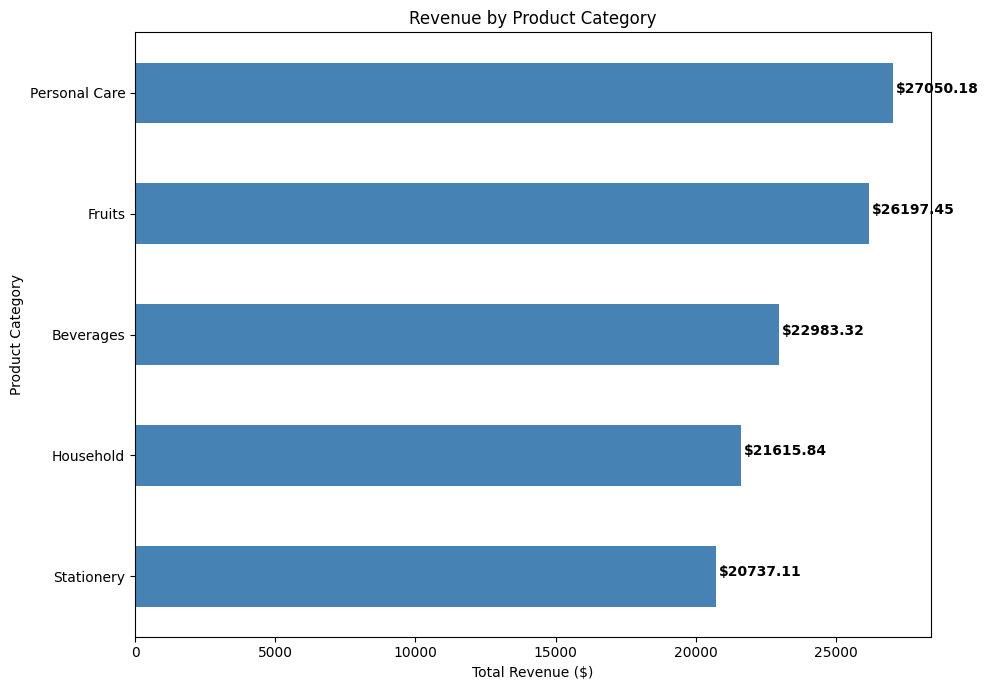

In [12]:
ax = revenue_by_category.sort_values().plot(kind = "barh",
                         title = "Revenue by Product Category",
                         xlabel = "Total Revenue ($)",
                         ylabel = "Product Category",
                         color = "steelblue",
                         figsize= (10,7))
for i, v in enumerate(revenue_by_category.sort_values()):
  ax.text(v+100, i, f"${v:.2f}", ha="left", fontweight="bold")

plt.tight_layout()
plt.show()

##Business Insight:
There is no dominant category category revenue, suggesting a balanced product mix. The company should maintain investment across all categories while exploring promotions for Stationery and Household to close the small gap with top performers.

#Do Members spend more than Normal customers?

In [14]:
revenue_by_customer = df.groupby("customer_type")["total_price"].sum()
print(revenue_by_customer)

customer_type
Member    63213.63
Normal    55370.27
Name: total_price, dtype: float64


##Finding:
Members generate higher total revenue compared to Normal customers, a difference of approximately $7,800.


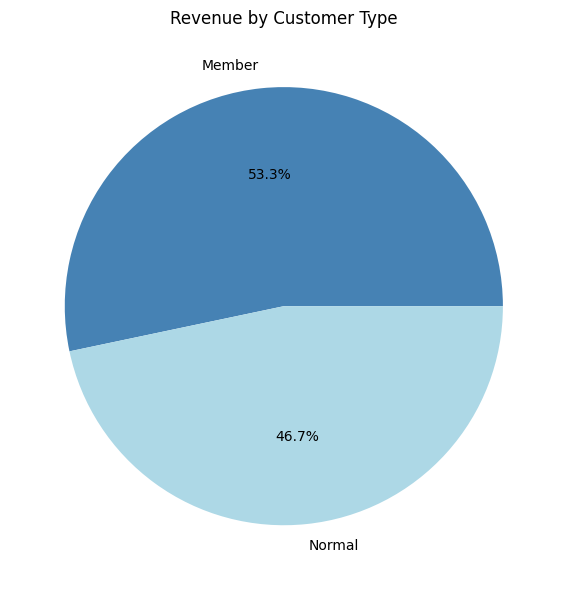

In [17]:
revenue_by_customer.plot(kind = "pie",
                         title = "Revenue by Customer Type",
                         autopct= "%1.1f%%",
                         colors = ["steelblue", "lightblue"],
                         figsize=(6,6))
plt.ylabel('')
plt.tight_layout()
plt.show()

##Business Insight:
Members and Normal customers contribute
almost equally to total revenue (53% vs 47%), suggesting
that Normal customers are already highly engaged. Converting
them into Members through loyalty programs could increase
purchase frequency and average spending, potentially
shifting the balance significantly in favor of Members.

#Which customer type spends more per product category?

In [22]:
spendings_by_category = df.groupby(["product_category","customer_type"])["total_price"].sum()
print(spendings_by_category)

product_category  customer_type
Beverages         Member           11807.00
                  Normal           11176.32
Fruits            Member           14045.72
                  Normal           12151.73
Household         Member           11613.86
                  Normal           10001.98
Personal Care     Member           15370.60
                  Normal           11679.58
Stationery        Member           10376.45
                  Normal           10360.66
Name: total_price, dtype: float64


##Finding:
Members spend more in Personal care. This category is also the one that has the biggest gap between members and normal customers with a difference of almost $3,700

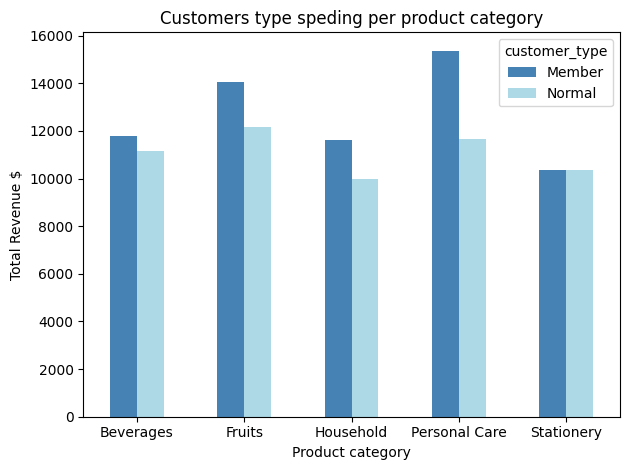

In [31]:
spending_pivot = spendings_by_category.unstack()

spending_pivot.plot(kind = "bar",
                     title = "Customers type spending per product category",
                     ylabel = "Total Revenue $",
                     xlabel = "Product category",
                     color = ["steelblue", "lightblue"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##Business Insight:
Personal Care is the category with the highest gap between Members and Normal customers. The company should launch targeted promotions to encourage Normal customers to spend more in this category, which could drive higher revenue and increase Member conversion.

#Which branch has the best overall performance?

In [17]:
revenue_by_branch = df.groupby(["branch", "city"])["total_price"].sum().reset_index()
print(revenue_by_branch)
avg_by_branch = df.groupby("branch")["total_price"].mean()
print(avg_by_branch)

  branch         city  total_price
0      A      Chicago     42584.71
1      A     New York     40226.93
2      B  Los Angeles     35772.26
branch
A    122.865935
B    109.730859
Name: total_price, dtype: float64


##Finding:
Branch A serves Chicago and New york, while Branch B serves only Los Angeles. The difference in average revenue per transaction is approximately $13.

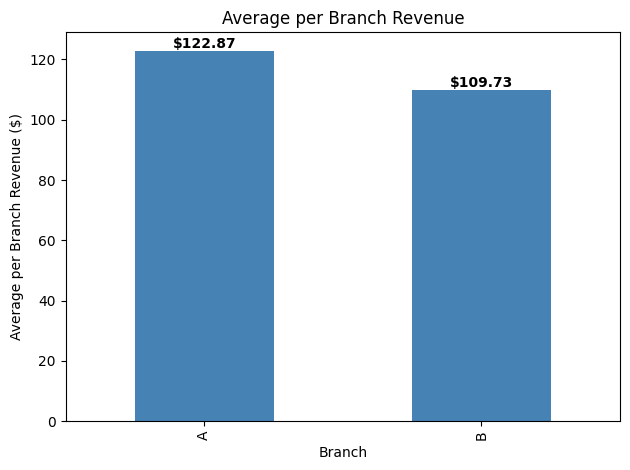

In [21]:
ax = avg_by_branch.plot (kind = "bar",
                    title = "Average per Branch Revenue",
                    xlabel = "Branch",
                    ylabel = "Average per Branch Revenue ($)",
                    color = "steelblue")
for i, v in enumerate (avg_by_branch):
  ax.text(i, v + 1, f"${v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

##Business Insight:
 Branch B's lower total revenue reflects market size, not underperformance. The company should investigate what drives Branch A's higher average transaction value, whether product mix, pricing, or customer profile, and replicate those learnings in branch B to increase per-transaction revenue.

#Conclusions
The analysis of 1,000 supermarket transactions reveals that Chicago and New York are the strongest markets, while Los Angeles presents an opportunity for growth through targeted marketing strategies. Across product categories, Personal Care and Fruits lead in revenue, though all five categories perform within a similar range, suggesting a balanced product mix. On the customer side, Members contribute slightly more revenue than Normal customers (53% vs 47%), and the gap is most pronounced in Personal Care — the category with the highest spending difference between the two groups — indicating that promotions in this category could drive both higher revenue and increased Member conversion. Finally, Branch B's lower total revenue reflects its single-city operation rather than underperformance, and should be evaluated in that context.










